In [1]:
from google.colab import files
uploaded = files.upload()

Saving matches.csv to matches.csv


(756, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-

/tmp/ipykernel_4365/364854582.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_winners.values, y=top_winners.index, palette='viridis')


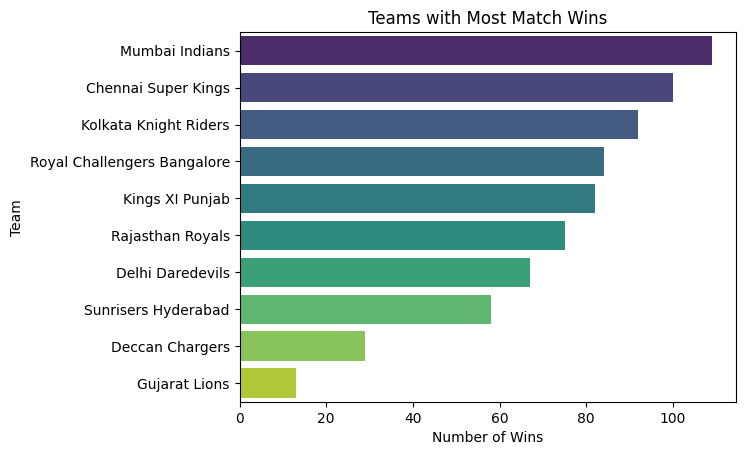

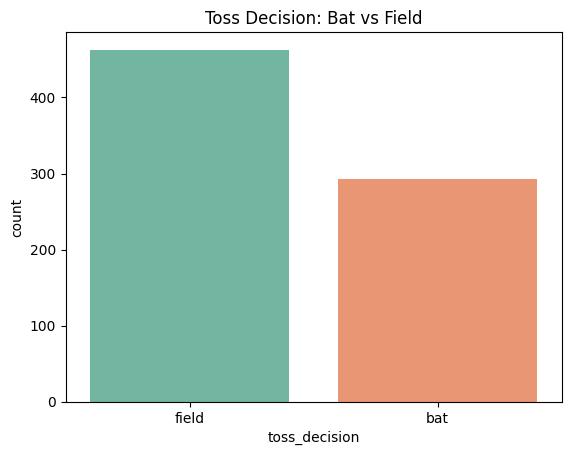

/tmp/ipykernel_4365/364854582.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='toss_match_win', data=df, palette='Set1')


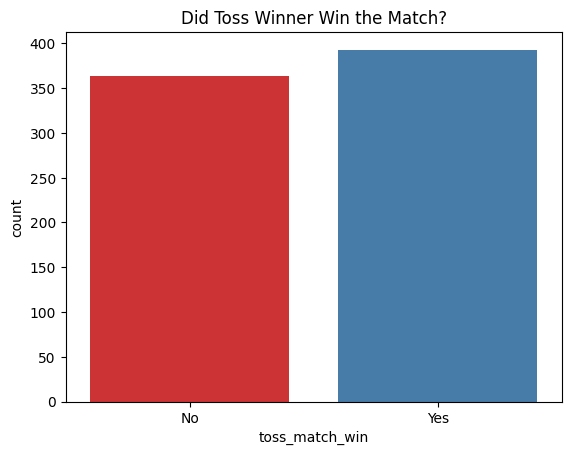

/tmp/ipykernel_4365/364854582.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')


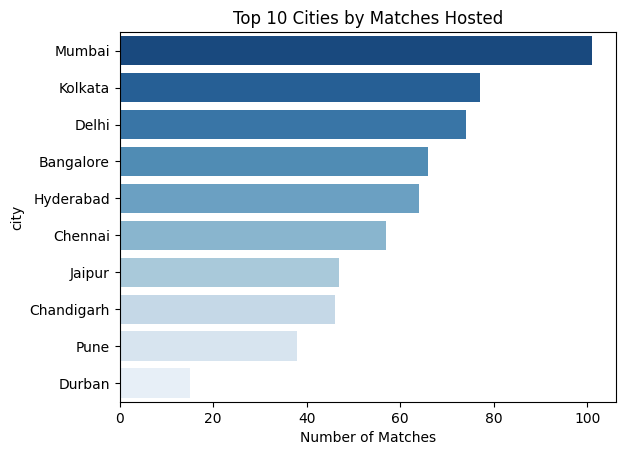

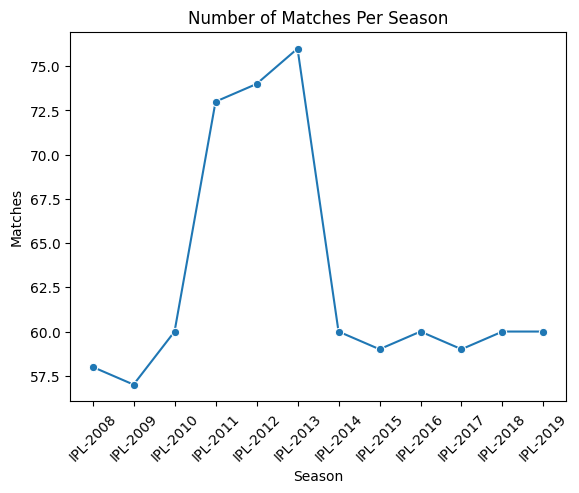

/tmp/ipykernel_4365/364854582.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pom.values, y=top_pom.index, palette='magma')


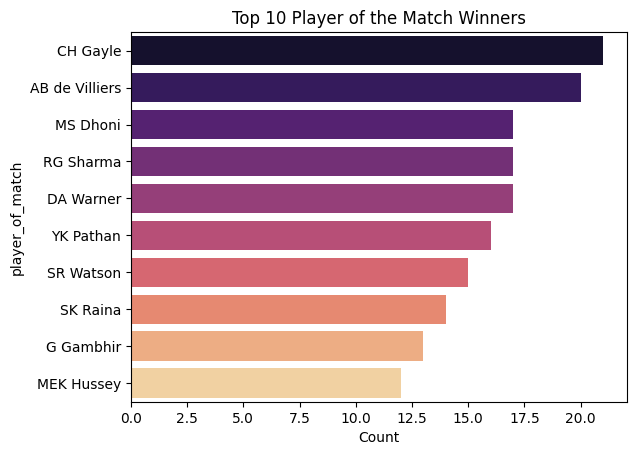

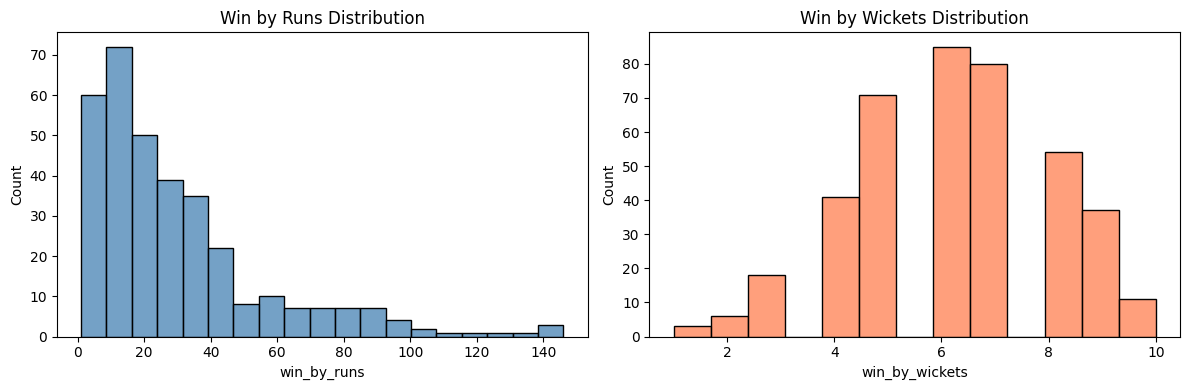

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("matches.csv")

print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

top_winners = df['winner'].value_counts().head(10)

sns.barplot(x=top_winners.values, y=top_winners.index, palette='viridis')
plt.title("Teams with Most Match Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.show()

sns.countplot(x='toss_decision', data=df, hue='toss_decision', palette='Set2', legend=False)
plt.title("Toss Decision: Bat vs Field")
plt.show()

df['toss_match_win'] = df['toss_winner'] == df['winner']

sns.countplot(x='toss_match_win', data=df, palette='Set1')
plt.title("Did Toss Winner Win the Match?")
plt.xticks([0,1], ['No', 'Yes'])
plt.show()
top_cities = df['city'].value_counts().head(10)

sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')
plt.title("Top 10 Cities by Matches Hosted")
plt.xlabel("Number of Matches")
plt.show()

matches_per_season = df['Season'].value_counts().sort_index()

sns.lineplot(x=matches_per_season.index, y=matches_per_season.values, marker='o')
plt.title("Number of Matches Per Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.xticks(rotation=45)
plt.show()

top_pom = df['player_of_match'].value_counts().head(10)

sns.barplot(x=top_pom.values, y=top_pom.index, palette='magma')
plt.title("Top 10 Player of the Match Winners")
plt.xlabel("Count")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df['win_by_runs'] > 0]['win_by_runs'], ax=axes[0], color='steelblue')
axes[0].set_title("Win by Runs Distribution")

sns.histplot(df[df['win_by_wickets'] > 0]['win_by_wickets'], ax=axes[1], color='coral')
axes[1].set_title("Win by Wickets Distribution")

plt.tight_layout()
plt.show()